# Reading OptoDas Data

This notebook provides minimal code to load the data, convert to strain, and plot

In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import cumulative_trapezoid
import glob

### Load data

In [ ]:
### NEED TO SPECIFY YOUR FILEPATH ###################################
files=glob.glob('/home/wdiens/notebooks/OOI_11-18/m6_oregon/*.hdf5')
files.sort()
#####################################################################

file_select = files[0]

### View meta-data
with h5py.File(file_select,'r') as fp:
    GL = fp['header/gaugeLength'][()]
    channels = fp['header/channels'][()]
    dx = fp['header/dx'][()] * channels[1]
    fs = 1/fp['header/dt'][()]
    data = fp['data'][()]
    nx = data.shape[1]
    ns = data.shape[0]
    sens=fp['header/sensitivities'][()]
    
    print(file_select)
    print('Gauge length (m):',GL)
    print('Channel spacing (m):',dx)
    print('Sampling rate (Hz):',fs)
    print('Num channels:',nx)
    print('Num samples:',ns)
    dt=1/fs

/home/wdiens/notebooks/OOI_11-18/m6_oregon/032001.hdf5
Gauge length (m): 40.85200763098726
Channel spacing (m): 10.213001907746815
Sampling rate (Hz): 8.000204805243014
Num channels: 10416
Num samples: 80


In [4]:
### Load data
data=[]
for i in files:
    dasfile=h5py.File(i,'r')
    data.append(np.array(dasfile['/data']))

### Stack data
data=np.array(data)
data_stacked = data.reshape(-1, data.shape[2])

### Critical to scale raw phase to strain
dataScale = (np.pi*2**-13)/(dt*GL)
dphi=data_stacked*dataScale
strain_rate = dphi/sens
strain = cumulative_trapezoid(strain_rate,axis=0, dx=dt)

/tmp/ipykernel_166016/2447448023.py:5: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  data.append(np.array(dasfile['/data']))


### Plot data

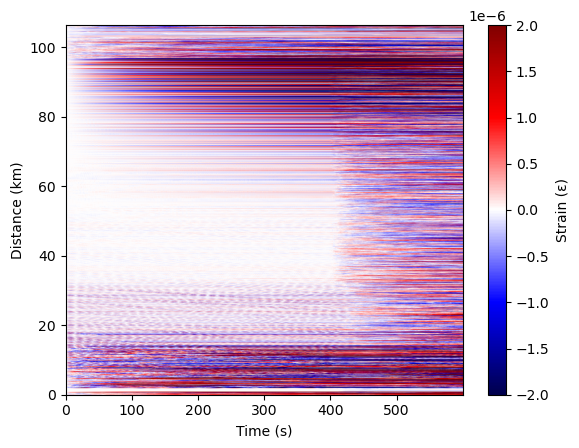

In [ ]:
vm=2e-6
xdec=8
tdec=1
c=plt.imshow(np.flipud(strain[::tdec,::xdec].T),aspect='auto',cmap='seismic',vmin=-vm,vmax=vm,extent=[0,strain.shape[0]/fs,0,strain.shape[1]*dx/1000])
plt.xlabel('Time (s)')
plt.ylabel('Distance (km)')
cbar=plt.colorbar(c)
cbar.set_label('Strain (ε)')

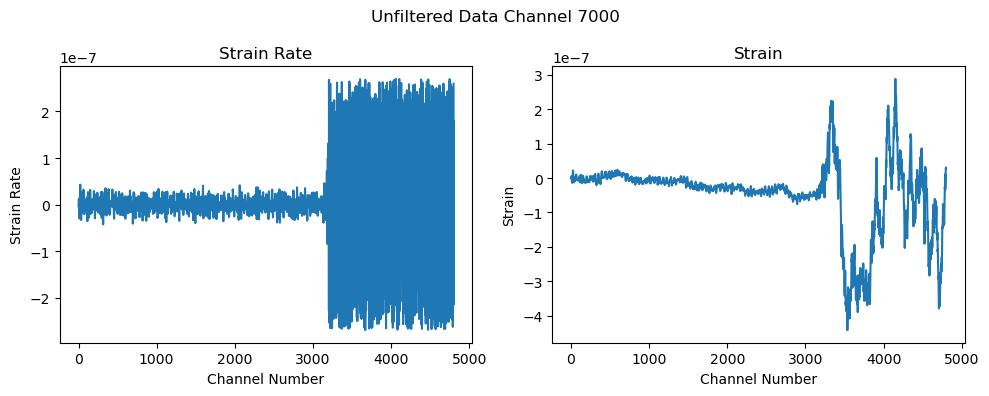

In [6]:
fig,ax=plt.subplots(1,2,figsize=(10,4))
chn=7000
ax[0].plot(strain_rate[:,chn])
ax[1].plot(strain[:,chn])
ax[0].set_title('Strain Rate')
ax[1].set_title('Strain')
plt.suptitle('Unfiltered Data Channel {}'.format(chn))
ax[0].set_xlabel('Channel Number')
ax[1].set_xlabel('Channel Number')
ax[0].set_ylabel('Strain Rate')
ax[1].set_ylabel('Strain')
plt.tight_layout()